<a href="https://colab.research.google.com/github/parika8ec-hub/AI_Assignment15/blob/main/Assignment15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task-1: Data Analysis and Cleaning



In [24]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
import shap

In [25]:
#Load and read bank loan dataset csv file
loan_data = pd.read_csv('bank-loan.csv')

print('Display few rows of dataset:')
print(loan_data.head().to_string())#display few rows of data

print('\nDataset Information:')
print(loan_data.info())#display information of data

print('\nDataset Summary Statistics:')
print(loan_data.describe())#display statistics summary of numeric columns of data

print('\nCheck missing values:')
print(loan_data.isnull().sum())#check missing values

#Fill missing values using nedian
loan_data.fillna(loan_data.median(), inplace=True)

#Verify filling of missing values
print('\nIs there any missing values after filling?',loan_data.isnull().sum().any())

Display few rows of dataset:
   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       850 non-null    int64  
 1   ed        850 non-null    int64  
 2   employ    850 non-null    int64  
 3   address   850 non-null    int64  
 4   income    850 non-null    int64  
 5   debtinc   850 non-null    float64
 6   creddebt  850 non-null    float64
 7   othdebt   850 non-null    float64
 8   

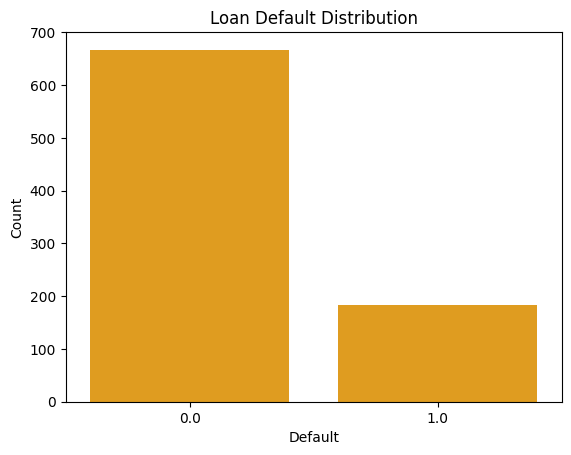

In [26]:
#Create a count plot for class distribution
sns.countplot(x='default', data=loan_data,color='orange')
plt.title("Loan Default Distribution")#add title
plt.xlabel("Default")#add x-axis label
plt.ylabel("Count")#add y-axis label
plt.show()#display plot

**Insight of Loan Default Distribution Plot:**

The plot shows more non-default (0) cases than default (1) means the dataset is noticeably imbalanced.

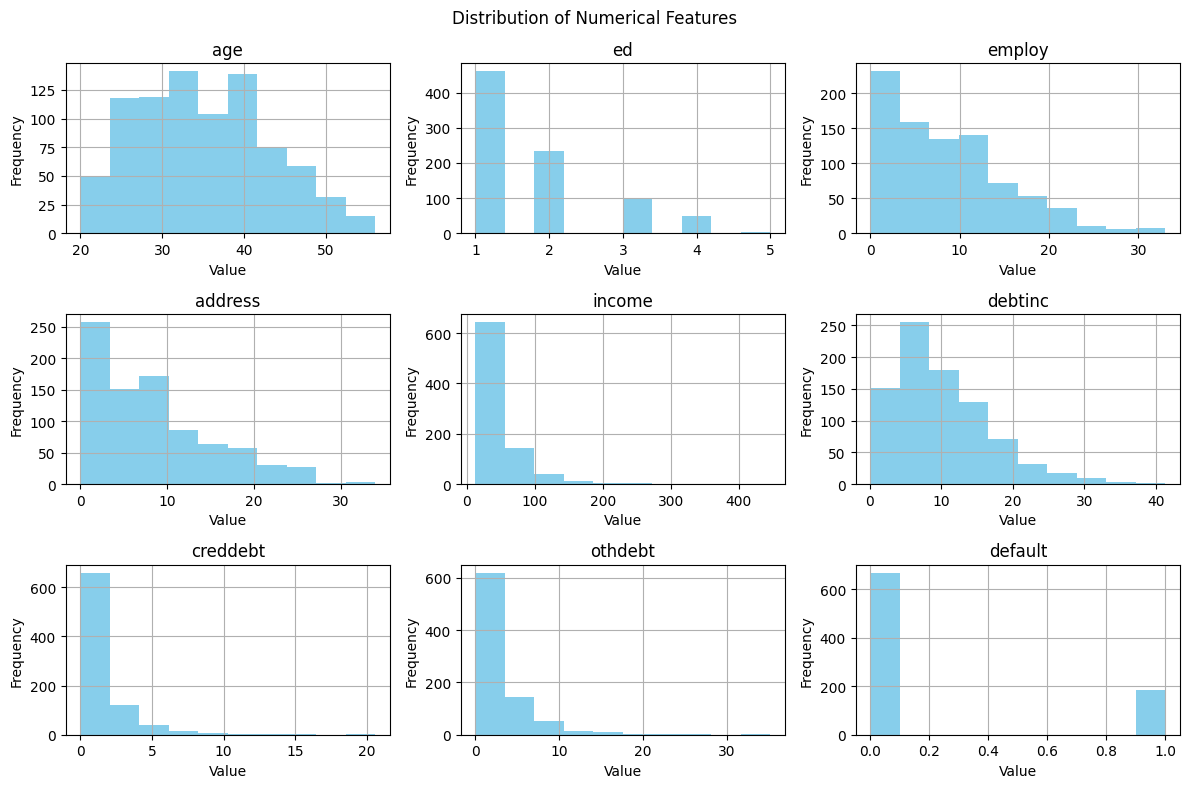

In [27]:
#Create a histogram for Numerical Distribution plot
loan_data.hist(figsize=(12,8), bins=10,color='skyblue')
plt.suptitle("Distribution of Numerical Features")#add main title

# Add axis labels for each subplot
for ax in plt.gcf().axes:
    #Add label of axis
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")

plt.tight_layout()#set tight layout for better visualization
plt.show()#display plot

**Insight of distribution plots:**

These plots indicate that most numerical features (income, debts) are right-skewed, meaning a small number of individuals have very high values. This skewness can affect model learning and may require transformation for better performance.

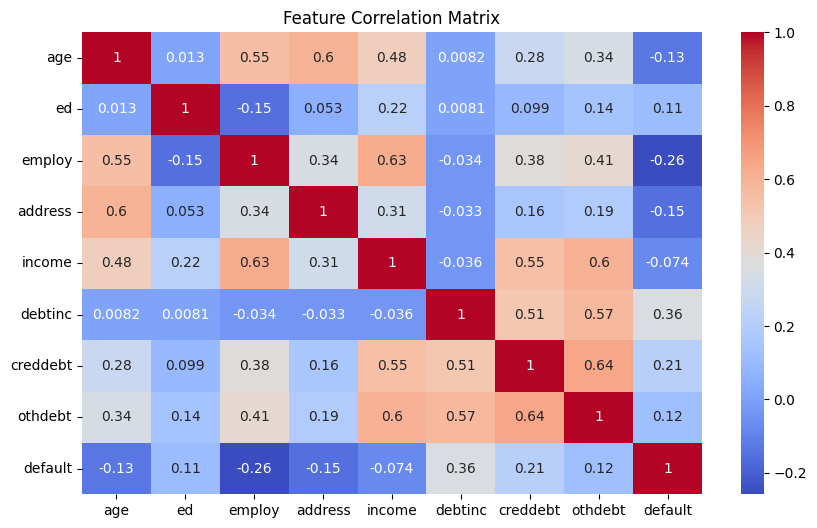

In [28]:
#Create heatmap for relationship between all variables using correlation heatmap
plt.figure(figsize=(10,6))#set plot size
#create correlation heatmap
sns.heatmap(loan_data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")#add title
plt.show()#display plot

**Insights of Correlation Matrix:**

From the correlation matrix, features such as income, employ (years of employment) and debt-related variables (creddebt, othdebt) show mostly moderate positive relationships with each other, indicating interconnected financial behaviors. Default shows weak to moderate correlation with debt-to-income ratio and debt features, suggesting that while these variables are relevant, no single feature strongly explains default on its own. This justifies the need for a multivariate model but also hints at complexity in prediction.

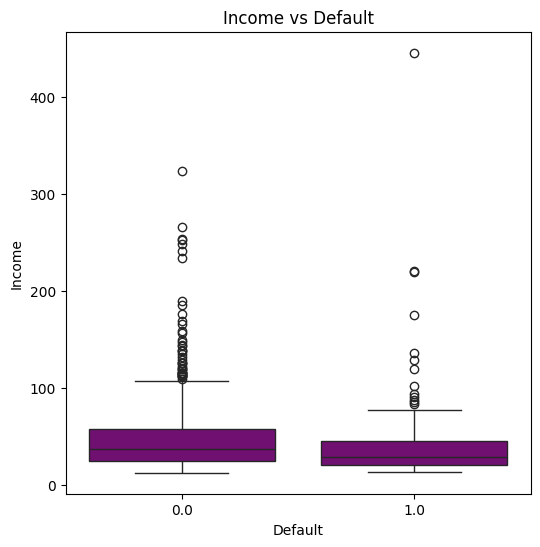

In [29]:
plt.figure(figsize=(6,6))#set plot size
#Create box plot for Income vs Default
sns.boxplot(x='default', y='income', data=loan_data,color='purple')
plt.title("Income vs Default")#add title
plt.xlabel("Default")#add label
plt.ylabel("Income")#add label
plt.show()#display plot

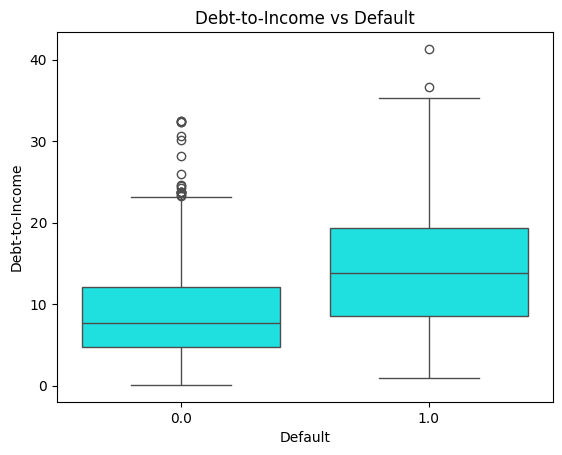

In [30]:
#Create box plot for Debt-to-Income vs Default
sns.boxplot(x='default', y='debtinc', data=loan_data,color='cyan')
plt.title("Debt-to-Income vs Default")#add title
plt.xlabel("Default")#add label
plt.ylabel("Debt-to-Income")#add label
plt.show()#display plot

**Insights of Boxplots:**

The income vs default and debt-to-income vs default boxplots reveal meaningful patterns, defaulters tend to have slightly lower median income and significantly higher debt-to-income ratios. This aligns with financial intuition and higher financial burden relative to income increases default risk. However, there is still substantial overlap between the groups, which explains why the model cannot perfectly separate them.

In addition, both features show the presence of outliers in each class. Income contains a few very high-income individuals in both default and non-default groups, indicating that high earners are not completely risk-free. Similarly, debt-to-income ratio has extreme high outliers, especially among defaulters, representing individuals with exceptionally high financial stress. These outliers can influence model learning by stretching the distribution and may require careful handling or transformation.

In [31]:
#Handle outliers
for col in ['income','debtinc','creddebt','othdebt']:
    q1 = loan_data[col].quantile(0.25) # Calculate first quartile (Q1) - 25th percentile
    q3 = loan_data[col].quantile(0.75) # Calculate third quartile (Q3) - 75th percentile
    iqr = q3 - q1 # Compute Interquartile Range (IQR)
    # Keep only values within acceptable range, no extreme outliers in dataset
    loan_data = loan_data[(loan_data[col] >= q1 - 1.5*iqr) & (loan_data[col] <= q3 + 1.5*iqr)]

print('After handling outliers, original dataset shape:')
print(loan_data.shape)#shape of updated dataset

After handling outliers, original dataset shape:
(678, 9)


**Note:**

1) The dataset does not contain explicit categorical (text-based) variables.
The education feature (ed) is already ordinally encoded (values 1–5), so no additional encoding was required.

2) Data normalization (scaling) was performed after feature engineering to ensure all derived features were
on a consistent scale for model training.


# Task-2: Feature Engineering

New features were created to enhance the model’s ability to identify hidden patterns that are not directly observable in the original variables and to better represent financial behavior by combining related attributes such as income, debt, age and education. Although the dataset already contains important financial and demographic information, transforming and integrating these variables enables the model to learn deeper and more meaningful relationships associated with loan default risk.



In [32]:
#Add new columns as below in dataset

# Create total debit feature by combining credit debit and other debit
# This gives a better representation of overall financial burden
loan_data["total_debt"] = loan_data["creddebt"] + loan_data["othdebt"]

# Create total debit to income ratio feature, which measures how much debit a person has relative to their income
loan_data["tot_debt_to_income"] = loan_data["total_debt"] / loan_data["income"]

# Create income per age feature, which captures earning efficiency relative to age
loan_data["income_per_age"] = loan_data["income"] / loan_data["age"]

# Create employment stability feature, which represents job stability as years employed relative to age
loan_data["employ_stability"] = loan_data["employ"] / loan_data["age"]

# Create income per education feature, which measures income level adjusted by education level
# Note: +1 is added to avoid division by zero error
loan_data["income_per_education"] = loan_data["income"] / (loan_data["ed"] + 1)

print('Updated Original Dataset:')
print(loan_data.head().to_string())#display updated dataset

Updated Original Dataset:
   age  ed  employ  address  income  debtinc  creddebt   othdebt  default  total_debt  tot_debt_to_income  income_per_age  employ_stability  income_per_education
1   27   1      10        6      31     17.3  1.362202  4.000798      0.0       5.363               0.173        1.148148          0.370370             15.500000
2   40   1      15       14      55      5.5  0.856075  2.168925      0.0       3.025               0.055        1.375000          0.375000             27.500000
4   24   2       2        0      28     17.3  1.787436  3.056564      1.0       4.844               0.173        1.166667          0.083333              9.333333
5   41   2       5        5      25     10.2  0.392700  2.157300      0.0       2.550               0.102        0.609756          0.121951              8.333333
7   43   1      12       11      38      3.6  0.128592  1.239408      0.0       1.368               0.036        0.883721          0.279070             19.000000


In [33]:
#Select features and target
X = loan_data.drop('default', axis=1)#take feature columns excluding default column
y = loan_data['default']#take default as target column

#Feature scaling/normalization
scaler = StandardScaler()#initialize scaler
# Apply feature scaling to standardize all numerical features and this transforms data to have mean = 0 and
# standard deviation = 1, ensuring all features contribute equally to the model
X_scaled= scaler.fit_transform(X)
#Convert scaled data into dataframe
scaled_data = pd.DataFrame(X_scaled, columns=X.columns)
scaled_data['default'] = y.values#add column as default in scaled_data dataframe
print('Scaled Data:')
print(scaled_data.head().to_string())#display few rows of scaled data

#Add original ed column to scaled_data dataframe to compare original and scaled value of education level, and for further insights
scaled_data['ed_original'] = loan_data['ed'].values #add ed_original column with original ed values
print('\nScaled Data with Original Education Level:')
print(scaled_data.head().to_string())#display few rows of updated scaled data

ed_Levels=dict()#store education level with scaled level value

#Display scaled value with original education level
for level in sorted(scaled_data['ed_original'].unique()):#take each unique education level
    scaled_val = scaled_data[scaled_data['ed_original'] == level]['ed'].iloc[0]#take scaled value of original education level by comparison

    print(f"\nEducation Level {level} → Scaled Value: {round(scaled_val, 4)}")#display result
    ed_Levels[round(scaled_val, 4)] = level #add to dictionary


Scaled Data:
        age        ed    employ   address    income   debtinc  creddebt   othdebt  total_debt  tot_debt_to_income  income_per_age  employ_stability  income_per_education  default
0 -0.880586 -0.730584  0.520251 -0.268314 -0.250455  1.645175  0.599689  1.569999    1.407892            1.645175        0.233726          1.169376              0.159295      0.0
1  0.817027 -0.730584  1.405617  0.953629  1.100806 -0.597466 -0.064813  0.192245    0.114128           -0.597466        0.754447          1.201323              1.727317      0.0
2 -1.272343  0.390085 -0.896335 -1.184770 -0.419363  1.645175  1.157985  0.859839    1.120696            1.645175        0.276233         -0.811317             -0.646494      1.0
3  0.947612  0.390085 -0.365116 -0.421056 -0.588270  0.295790 -0.673185  0.183502   -0.148719            0.295790       -1.002112         -0.544835             -0.777163      0.0
4  1.208783 -0.730584  0.874397  0.495400  0.143663 -0.958569 -1.019936 -0.506846   -0.80279

# Task-3: Model Building and Evaluation

In [34]:
#Split scaled data into 80% training and 20% testing set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Logistic regression model initialization
LR_model = LogisticRegression()

#Fit model on training set
LR_model.fit(X_train, y_train)

#Predict data on testing set
y_pred = LR_model.predict(X_test)

#Calculate acccuracy of model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,4))#display result

#Compute confusion matrix of data
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)#display result

#Display classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.7647

Confusion Matrix:
[[100   7]
 [ 25   4]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.80      0.93      0.86       107
         1.0       0.36      0.14      0.20        29

    accuracy                           0.76       136
   macro avg       0.58      0.54      0.53       136
weighted avg       0.71      0.76      0.72       136



**Insights of Logistic Regression Results:**

The overall accuracy of model (0.7647) appears acceptable, the model performs poorly on the minority (default) class as 1, with low precision and recall. This imbalance, combined with the fairness disparities across education levels, highlights a key issue as the model is both performance-limited and inequitable.

This imbalance is reflected in the model's performance, where it achieves high accuracy overall but struggles to correctly identify default cases, as seen in the confusion matrix and low recall (0.14) for the positive class. This means the model is biased toward predicting non-default, which can be risky in real-world financial decision-making.

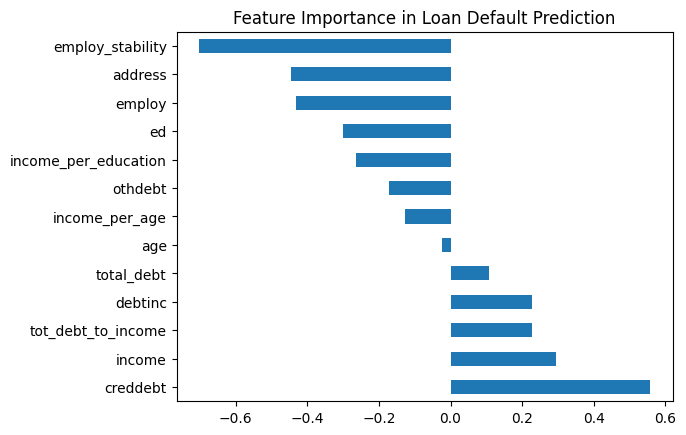

In [35]:
# Extract feature importance from Logistic Regression model coefficients, where coefficients indicate the
# strength and direction of each feature's impact on prediction
feature_importance = pd.Series(LR_model.coef_[0], index=X.columns)

# Sort feature importance values in descending order for better visualization
feature_importance.sort_values(ascending=False).plot(kind="barh")

# Add title
plt.title("Feature Importance in Loan Default Prediction")

plt.show()#display plot

**Insight of Feature Importance Plots:**

Features like employ_stability, address and employ have the strongest influence on predictions, with their negative SHAP values indicating that they primarily reduce the likelihood of default.

# Task-4: Explainability and Fairness Analysis


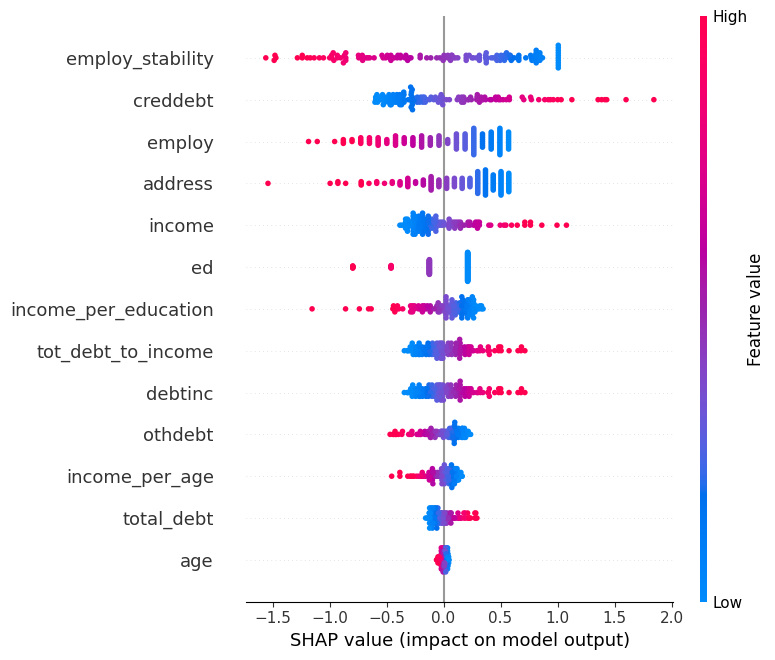

In [36]:
# Convert X_test back to DataFrame to retain feature names, which is important for SHAP visualizations to display correct feature labels
X_test = pd.DataFrame(X_test, columns=X.columns)

# Create SHAP explainer for Logistic Regression model and LinearExplainer is used because Logistic Regression is a linear model
explainer = shap.LinearExplainer(LR_model, X_train)

# Compute SHAP values for test dataset and these values show the contribution of each feature to predictions
shap_values = explainer.shap_values(X_test)

# Global feature importance visualization (summary plot) shows overall impact of each feature across all predictions
shap.summary_plot(shap_values, X_test)

**Insights of SHAP analysis:**

It indicates that higher employment stability lowers the probability of default, whereas higher debt ratios increase it. Interestingly, education (ed) shows a mixed but noticeable effect, meaning it influences the prediction to some extent but is not a primary determining factor.

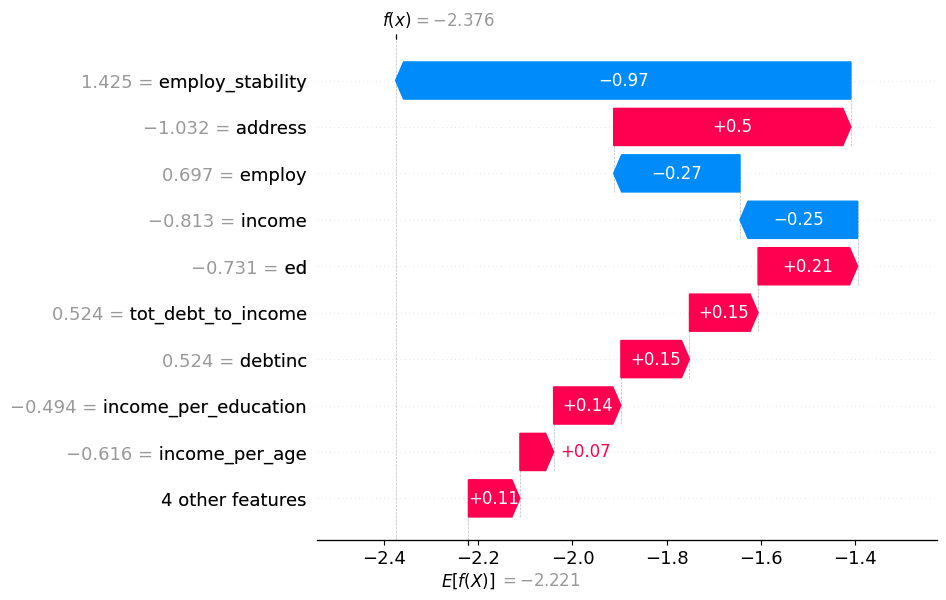

In [37]:
#Individual Prediction Explanation (Waterfall Plot)

# Waterfall plot explains a single prediction in detail.It shows how each feature contributes to pushing the
# prediction higher (towards default) or lower (towards non-default)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],              # SHAP values for the selected instance
        base_values=explainer.expected_value,  # Average model output (baseline prediction)
        data=X_test.iloc[0],                # Feature values for the first test sample
        feature_names=X.columns             # Names of features for better interpretability
    )
)

**Insights of SHAP waterfall plot:**

It explains how the model prediction shifts from the baseline value -2.221 to the final output -2.376 for a single individual. The final prediction is slightly lower than average, indicating a reduced risk of default.

The strongest protective factor is employment stability (employ_stability), which significantly lowers the prediction (-0.97). Other features like employment (-0.27) and income (-0.25) also reduce risk, showing that stable jobs and higher income strongly support non-default outcomes.

In contrast, address (+0.50) increases risk, possibly reflecting shorter residence stability. Debt-related features such as debt-to-income ratio and debtinc (+0.15 each) also push the prediction toward higher default risk. Education (ed) contributes a small positive effect (+0.21), slightly increasing risk in this case.

Overall, the prediction is dominated by strong employment-related protective factors, outweighing debt and other risk indicators, resulting in a non-default outcome. From a fairness perspective, the influence of education suggests potential variation across groups, highlighting the need to monitor bias in model decisions.

In [38]:
#Fairness Analysis Across Demographic Groups as Education Group
# ---------------------------------------------------------------

# Create a copy of test features for fairness evaluation
df_test = X_test.copy()

# Add actual target values (true loan default labels)
df_test["actual"] = y_test.values

# Add model predictions
df_test["predicted"] = y_pred

# Create group column based on education level, which will be used to compare model performance across education groups
df_test["ed_group"] = df_test["ed"]

# Accuracy comparison across groups
# ----------------------------------------------------------------
# Evaluate model accuracy separately for each education level
for group in sorted(df_test["ed_group"].unique()):#take each education level
    subset = df_test[df_test["ed_group"] == group]#create subset of selected education level
    acc = accuracy_score(subset["actual"], subset["predicted"])#compute accuraccy score against education level
    print(f"Education Level: {ed_Levels[round(group,4)]}, Scaled Level: {round(group,4)}, Accuracy: {round(acc,4)}")#display education level with sccuracy score

# Selection rate comparison
# ------------------------------------------------------------------
# Calculate average prediction rate, which helps identify potential bias across different groups
df_test.groupby("ed_group")["predicted"].mean()

Education Level: 1, Scaled Level: -0.7306, Accuracy: 0.825
Education Level: 2, Scaled Level: 0.3901, Accuracy: 0.7317
Education Level: 3, Scaled Level: 1.5108, Accuracy: 0.625
Education Level: 4, Scaled Level: 2.6314, Accuracy: 0.4286


,predicted
ed_group,
-0.730584,0.062500
0.390085,0.121951
1.510754,0.000000
2.631423,0.142857


**Insights of Fairness Analysis Across Demographic Groups:**

From a fairness perspective across education groups, there is a clear disparity. As education level increases (from Level 1 to Level 4), model accuracy drops sharply from 0.825 to 0.4286. Additionally, prediction rates vary inconsistently, with some groups (e.g., Level 3) receiving almost no positive predictions. This suggests that the model is not generalizing well across education groups and may be biased toward patterns dominant in lower education levels. Such disparities indicate potential indirect discrimination, where certain groups receive less reliable predictions.

**Analysis of fairness and recommendations for improvements:**

The SHAP analysis shows that the most influential features in predicting loan default are employment stability, income, and debt-related variables such as debt-to-income ratio and credit debt. These factors strongly guide the model's decisions, indicating that financial burden and job stability are key determinants of default risk. The waterfall plot for an individual prediction further explains how specific features either increase or decrease the likelihood of default, improving transparency in model behavior.

From a fairness perspective across education groups, there is a clear disparity in model performance. As education level increases (from Level 1 to Level 4), model accuracy drops sharply from 0.825 to 0.4286. In addition, prediction behavior becomes inconsistent, with some higher education groups receiving very few or no positive predictions, suggesting unstable model generalization across groups. This indicates that the model may be biased toward patterns learned from lower education levels, leading to weaker performance for higher education groups.

Overall, while the model performs well in general, these results highlight potential fairness concerns, including uneven accuracy and skewed prediction rates across education levels. This suggests the need for further improvements such as addressing class imbalance, ensuring sufficient representation of all groups, and applying fairness-aware techniques to reduce bias and improve consistency across demographic groups.

# Task-5: Ethical Considerations

Ethical AI development requires careful attention to fairness, privacy and transparency, especially when models are used for sensitive decisions such as loan default prediction. In this project, these aspects were considered throughout the data processing, model training and evaluation stages to ensure responsible and interpretable outcomes.

**Fairness Considerations**

Fairness was evaluated by analyzing model performance across different demographic groups, particularly education levels. The results showed noticeable disparities, where accuracy decreased significantly as education level increased (from approximately 0.825 to 0.4286). Additionally, some groups showed highly imbalanced prediction behavior, with very few positive (default) predictions.

These findings indicate that the model may not generalize equally across all groups and could be influenced by representation imbalance in the training data. Groups with fewer samples or different feature distributions may receive less reliable predictions, leading to potential indirect bias.

To address fairness concerns, the following improvements are recommended:

*	Use resampling techniques (e.g., SMOTE or stratified sampling) to balance group representation.

*	Apply fairness-aware algorithms or constraints (e.g., demographic parity, equal opportunity).

*	Perform continuous group-wise evaluation metrics instead of relying only on overall accuracy.

*	Reassess sensitive or proxy variables (such as education) to ensure they do not unintentionally introduce bias.



**Privacy Considerations**

Privacy was maintained by using only structured, anonymized tabular data, without any personally identifiable information such as names, addresses or account numbers. Features like income, debt and employment-related attributes were used in aggregated or encoded form to reduce exposure of sensitive information.

However, certain variables such as address and employment details may still indirectly reveal sensitive socio-economic patterns.

Therefore, care must be taken to ensure that:

*	Data is securely stored and accessed only for modeling purposes.

*	Sensitive attributes are minimized or transformed where possible.

*	Model outputs are not used to infer private personal details.

Future improvements could include applying data anonymization techniques or differential privacy methods to further strengthen privacy protection.

**Transparency and Explainability**

Transparency was a key focus in model development. Explainability techniques such as SHAP (SHapley Additive exPlanations) were used to interpret model predictions at both global and individual levels.

The SHAP analysis revealed that features such as employment stability, income related and debt-related variables were the most influential in predicting default risk. The waterfall plot further demonstrated how each feature contributes positively or negatively to a single prediction, improving interpretability and trust in the model.

This level of explainability helps stakeholders understand not only the final prediction but also the reasoning behind it, which is critical in high-stakes domains like finance.

To further improve transparency:

*	Provide user-facing explanations for predictions in simple language.

*	Combine SHAP with other interpretability methods (e.g., LIME for validation).

*	Document model assumptions and limitations clearly for stakeholders.

**Conclusion and Recommendations**

Overall, the model demonstrates strong predictive capability and good interpretability through SHAP analysis. However, fairness analysis reveals performance disparities across education groups, indicating potential bias and uneven generalization.

To improve ethical robustness, future work should focus on:

*	Enhancing fairness through balanced data and fairness constraints.

*	Strengthening privacy protections through anonymization and secure data handling.

*	Increasing transparency through consistent explainability techniques and stakeholder communication.

By addressing these aspects, the model can be made more fair, trustworthy, and ethically responsible, ensuring better real-world applicability in financial decision-making systems.